In [119]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
from datetime import datetime

In [166]:
termini = gpd.read_file('/Users/cjense/Desktop/phd/Data/Termini/combined_termini_79N_2.shp')
termini = termini.to_crs('EPSG:3413')

# Parse all available date sources and keep the first valid value in `Date`
source_dt = pd.to_datetime(termini["SourceDate"], errors="coerce")
ymd_dt = pd.to_datetime(termini[["Year", "Month", "Day"]], errors="coerce")
date_dt = pd.to_datetime(termini["Date"], errors="coerce") if "Date" in termini.columns else pd.Series(pd.NaT, index=termini.index)

termini["Date"] = source_dt.fillna(ymd_dt).fillna(date_dt)
termini = termini[
        termini['Date'].notna() & (termini['Date'] >= pd.Timestamp("2000-01-01"))
    ].reset_index(drop=True)
termini = termini.sort_values('Date')

termini.to_file('/Users/cjense/Desktop/phd/Data/Termini/combined_termini_79N_2.shp')
termini

/Users/cjense/Desktop/phd/ZI 79N Seasonality/.pixi/envs/default/lib/python3.14/site-packages/pyogrio/raw.py:733: RuntimeWarning: Field Date created as String field, though DateTime requested.
  ogr_write(


,id,Date,ImagePath,SLCFlag,Satellite,Time,cloudShado,notes,otherImage,partialPic,...,Day,DecDate,QualFlag,ImageID,Author,Center_X,Center_Y,layer,path,geometry
32,NaN,2000-07-02,NaN,NaN,Landsat,NaN,NaN,None,NaN,NaN,...,2.0,2000.500000,05,LE07_L1TP_011002_20000702_20170211_01_T1,PROMICE,-20.234724,79.752686,combined_termini_79N,/Users/cjense/Desktop/phd/Data/Termini/combine...,"LINESTRING (461898.916 -1020189.258, 461909.64..."
33,NaN,2000-07-02,NaN,NaN,Landsat,NaN,NaN,None,NaN,NaN,...,2.0,2000.500000,00,LE70110022000184EDC00,ESA,-19.466153,79.531948,combined_termini_79N,/Users/cjense/Desktop/phd/Data/Termini/combine...,"LINESTRING (491890.479 -1039677.534, 491842.93..."
34,NaN,2001-06-25,NaN,NaN,Landsat,NaN,NaN,None,NaN,NaN,...,25.0,2001.479452,05,LE07_L1TP_011002_20000702_20170211_01_T1,PROMICE,-20.243697,79.752838,combined_termini_79N,/Users/cjense/Desktop/phd/Data/Termini/combine...,"LINESTRING (461898.916 -1020189.258, 461899.26..."
35,NaN,2001-06-25,NaN,NaN,Landsat,NaN,NaN,None,NaN,NaN,...,25.0,2001.479452,05,LE07_L1TP_006003_19990713_20170218_01_T1,PROMICE,-19.503955,79.522821,combined_termini_79N,/Users/cjense/Desktop/phd/Data/Termini/combine...,"LINESTRING (484132.325 -1007711.923, 484199.72..."
36,NaN,2002-06-16,NaN,NaN,Landsat,NaN,NaN,None,NaN,NaN,...,16.0,2002.454795,05,LE07_L1TP_011002_20000702_20170211_01_T1,PROMICE,-20.250791,79.755214,combined_termini_79N,/Users/cjense/Desktop/phd/Data/Termini/combine...,"LINESTRING (461898.916 -1020189.258, 461917.24..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27,1_1_1_1_2_0_0,2025-04-09,LANDSAT/LC09/C02/T1_TOA/LC09_012002_20250409,0.0,LANDSAT_9,15:15:26.000,0.0,None,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,79N_thru2025,/Users/cjense/Downloads/79N_thru2025.geojson|g...,"MULTILINESTRING ((489474.644 -1040347.584, 489..."
28,1_1_1_2_0_0,2025-05-16,LANDSAT/LC09/C02/T1_TOA/LC09_047241_20250516,0.0,LANDSAT_9,20:26:43.000,0.0,None,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,79N_thru2025,/Users/cjense/Downloads/79N_thru2025.geojson|g...,"MULTILINESTRING ((489469.963 -1040513.981, 489..."
29,1_1_2_0_0,2025-07-11,LANDSAT/LC09/C02/T1_TOA/LC09_007003_20250711,0.0,LANDSAT_9,14:44:48.000,0.0,None,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,79N_thru2025,/Users/cjense/Downloads/79N_thru2025.geojson|g...,"MULTILINESTRING ((473139.561 -1015480.378, 471..."
30,1_2_0_0,2025-08-06,LANDSAT/LC09/C02/T1_TOA/LC09_013002_20250806,0.0,LANDSAT_9,15:21:43.000,1.0,None,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,79N_thru2025,/Users/cjense/Downloads/79N_thru2025.geojson|g...,"MULTILINESTRING ((473115.284 -1015469.931, 473..."


[INFO] (Timestamp('2000-07-02 00:00:00'),): 2 traces -- combining into a single boundary (same author, same date)
[INFO] (Timestamp('2001-06-25 00:00:00'),): 2 traces -- combining into a single boundary (same author, same date)
[INFO] (Timestamp('2002-06-16 00:00:00'),): 2 traces -- combining into a single boundary (same author, same date)
[INFO] (Timestamp('2003-07-22 00:00:00'),): 2 traces -- combining into a single boundary (same author, same date)
[INFO] (Timestamp('2005-07-20 00:00:00'),): 2 traces -- combining into a single boundary (same author, same date)
[INFO] (Timestamp('2005-07-23 00:00:00'),): 3 traces -- combining into a single boundary (same author, same date)
[INFO] (Timestamp('2007-07-06 00:00:00'),): 2 traces -- combining into a single boundary (same author, same date)
[INFO] (Timestamp('2007-08-11 00:00:00'),): 2 traces -- combining into a single boundary (same author, same date)
[INFO] (Timestamp('2008-05-08 00:00:00'),): 2 traces -- combining into a single boundary

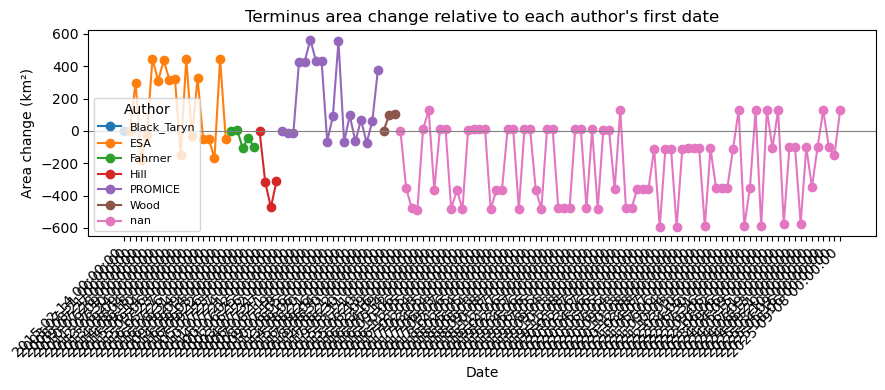

In [168]:
"""
Terminus area-change calculation with per-date, per-author polygon
visualization.

v23 changes (from v22):
  - NEW: fragment-to-fragment endpoint linking. When a date/author's
    trace clips into MULTIPLE open parts (e.g. a MultiLineString with
    disjoint pieces, or several separate LineStrings), each free
    endpoint used to always snap straight to the box boundary. Now,
    before any box-snapping happens, build_connectors() checks whether
    a free endpoint is actually CLOSER to another fragment's free
    endpoint than it is to the box edge -- if so, those two fragments
    are stitched directly to each other with a straight connector
    instead of each being snapped independently to the box (which
    could otherwise carve the box edge into the middle of what should
    be one continuous ice edge).
      * Matching is greedy nearest-pair-first: all candidate
        cross-fragment endpoint pairs are sorted by distance and
        matched off (skipping any endpoint already used), but a pair
        is only ever connected when its distance is LESS than BOTH
        endpoints' individual distances to the box boundary -- so an
        endpoint only ever prefers another fragment's endpoint when
        that's genuinely the better option.
      * Endpoints on the SAME part are never paired with each other
        here (a part's own two ends coinciding is the existing closed-
        loop case from v22, handled separately).
      * Any endpoint left unmatched after that pairing pass falls back
        to the normal box-snap connector, exactly as before.
      * build_connectors() now returns (box_connectors,
        fragment_connectors) instead of a single list, so
        close_terminus()/resplit_flagged_date() feed both into the
        noded network the same way, and plot_date() can draw them
        differently: box connectors stay black/dashed, fragment-to-
        fragment connectors are drawn in blue/dash-dot so it's obvious
        at a glance which pieces got stitched to each other instead of
        to the box.

Everything else (v22's closed-loop hole handling, per-author
grouping/plots, tip trimming with the stable-run guard, precision
snapping, manual box-ring-cut recovery for no_split dates, the single
area-sanity check) is unchanged from v22.
"""

import os
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString, MultiLineString, Polygon
from shapely.ops import linemerge, polygonize, unary_union, nearest_points, substring
from shapely import set_precision

# ----------------------------- CONFIG ------------------------------
TERMINI_PATH = "/Users/cjense/Desktop/phd/Data/Termini/combined_termini_79N_2.shp"
BOX_PATH = "/Users/cjense/Desktop/phd/Data/Termini/boundingbox_79N.shp"
DATE_FIELD = "Date"

# NOTE: update this to match the actual author/source column name in
# your shapefile's attribute table.
AUTHOR_FIELD = "Author"

x_pt = 455799
y_pt = -1046113
ICE_REF_XY = (x_pt, y_pt)

# Discard candidate ice-side polygons smaller than this (m^2) -- filters
# out slivers created by self-intersections/overlap noise.
MIN_POLYGON_AREA = 1000

# Coordinate precision grid (meters) used to snap all geometries before
# noding/polygonizing. Must be coarse enough to absorb floating-point
# noise from repeated geometric ops, but far finer than any real
# feature you care about. 1 cm is a safe default for meter-scale data.
PRECISION_GRID = 0.01

# When trimming an outside tip back to the box, ignore any crossing
# that isn't followed by a genuinely stable "inside" run at least this
# long (map units, e.g. meters).
MIN_STABLE_RUN_LENGTH = 50

# Tolerance (map units) for deciding a trace part's two endpoints
# coincide -- i.e. it's a closed loop that connects back to itself.
CLOSED_LOOP_TOL = 1e-3

# --- single source of truth for the "is this area even real" sanity
# check. If ice_poly comes back bigger than this, the split didn't
# actually cut anything (classic full-box-returned failure) and the
# date is treated exactly like a no_split -- everywhere. Set this a
# bit below your box's true full area.
AREA_SANITY_MAX_KM2 = 3000
AREA_SANITY_MAX_M2 = AREA_SANITY_MAX_KM2 * 1e6

OUTPUT_DIR = "terminus_qc_plots_79N"
# ---------------------------------------------------------------------


def snap(geom):
    return set_precision(geom, PRECISION_GRID)


def is_closed_line(line, tol=CLOSED_LOOP_TOL):
    """True if `line`'s two endpoints coincide (within tol) -- i.e. it
    connects back to itself and forms a closed loop, wherever that
    happens (fully inside the box, touching the box boundary, etc.)."""
    coords = list(line.coords)
    if len(coords) < 4:
        return False
    return Point(coords[0]).distance(Point(coords[-1])) < tol


def subtract_holes(ice_poly, closed_parts):
    """Punch each closed-loop part out of ice_poly as a hole, when that
    loop actually sits inside the selected ice-side polygon. polygonize()
    treats a disjoint ring as its own separate face rather than a hole in
    the surrounding polygon, so this is done explicitly here instead."""
    if ice_poly is None or not closed_parts:
        return ice_poly

    for cp in closed_parts:
        try:
            hole_poly = Polygon(cp.coords)
        except Exception:
            continue
        if not hole_poly.is_valid:
            hole_poly = hole_poly.buffer(0)
        if hole_poly.is_empty:
            continue
        rep_pt = hole_poly.representative_point()
        if ice_poly.contains(rep_pt) or ice_poly.intersects(hole_poly):
            ice_poly = ice_poly.difference(hole_poly)

    return ice_poly


def extract_crossing_points(geom):
    if geom.is_empty:
        return []
    if geom.geom_type == "Point":
        return [geom]
    if geom.geom_type == "MultiPoint":
        return list(geom.geoms)
    if geom.geom_type == "GeometryCollection":
        pts = []
        for g in geom.geoms:
            pts.extend(extract_crossing_points(g))
        return pts
    if geom.geom_type == "LineString":
        return [Point(geom.coords[0]), Point(geom.coords[-1])]
    if geom.geom_type == "MultiLineString":
        pts = []
        for g in geom.geoms:
            pts.extend(extract_crossing_points(g))
        return pts
    return []


def compute_runs(line, box, crossing_dists):
    breakpoints = sorted(set([0.0] + list(crossing_dists) + [line.length]))
    runs = []
    for i in range(len(breakpoints) - 1):
        s, e = breakpoints[i], breakpoints[i + 1]
        if e - s < 1e-9:
            continue
        mid_pt = line.interpolate((s + e) / 2)
        runs.append((s, e, box.covers(mid_pt)))
    return runs


def trim_tips_to_box(line, box, min_stable_run):
    # Closed loops have no "tips" sticking out to trim -- leave them as-is.
    if is_closed_line(line):
        return line

    start_pt = Point(line.coords[0])
    end_pt = Point(line.coords[-1])

    crossings = line.intersection(box.exterior)
    pts = extract_crossing_points(crossings)
    dists = sorted(set(round(line.project(p), 6) for p in pts))
    runs = compute_runs(line, box, dists)

    new_start = 0.0
    new_end = line.length

    if not box.covers(start_pt):
        stable = next(
            (r for r in runs if r[2] and (r[1] - r[0]) >= min_stable_run), None
        )
        if stable is None:
            return None
        new_start = stable[0]

    if not box.covers(end_pt):
        stable = next(
            (r for r in reversed(runs) if r[2] and (r[1] - r[0]) >= min_stable_run),
            None,
        )
        if stable is None:
            return None
        new_end = stable[1]

    if new_start >= new_end:
        return None

    return substring(line, new_start, new_end)


def clip_to_box(geom, box):
    if geom.geom_type == "LineString":
        raw_parts = [geom]
    elif geom.geom_type == "MultiLineString":
        raw_parts = list(geom.geoms)
    else:
        raw_parts = []

    trimmed = []
    for part in raw_parts:
        t = trim_tips_to_box(part, box, MIN_STABLE_RUN_LENGTH)
        if t is not None and not t.is_empty:
            trimmed.append(t)

    if not trimmed:
        return LineString()
    if len(trimmed) == 1:
        return trimmed[0]
    return MultiLineString(trimmed)


def get_parts(geom):
    """Return a flat list of LineString parts. Closed loops (endpoints
    coincide) are kept exactly as-is and are NEVER passed through
    linemerge() with the open parts -- merging could otherwise fuse a
    closed ring into an open part or otherwise mangle it. Open parts
    ARE merged end-to-end where they connect."""
    if geom.is_empty:
        return []
    if geom.geom_type == "LineString":
        lines = [geom]
    elif geom.geom_type == "MultiLineString":
        lines = list(geom.geoms)
    elif geom.geom_type == "GeometryCollection":
        lines = []
        for g in geom.geoms:
            if g.geom_type == "LineString":
                lines.append(g)
            elif g.geom_type == "MultiLineString":
                lines.extend(list(g.geoms))
    else:
        lines = []

    if not lines:
        return []

    closed = [l for l in lines if is_closed_line(l)]
    open_lines = [l for l in lines if not is_closed_line(l)]

    if not open_lines:
        return closed

    merged = linemerge(open_lines) if len(open_lines) > 1 else open_lines[0]
    if merged.geom_type == "MultiLineString":
        merged_parts = list(merged.geoms)
    else:
        merged_parts = [merged]

    return merged_parts + closed


def build_connectors(parts, box_boundary):
    """For every free endpoint left after tip-trimming (i.e. not
    already touching the box, and not part of a closed loop -- callers
    must filter closed parts out before calling this), first try to
    pair it with another fragment's free endpoint if that's actually
    CLOSER than the box boundary; only endpoints left unmatched after
    that pairing pass fall back to a straight box-snap connector.

    Fragment-to-fragment pairing rules:
      - Only endpoints belonging to DIFFERENT parts are ever paired
        with each other (a single part's own two ends coinciding is
        the closed-loop case, handled elsewhere).
      - Candidate pairs are matched off greedily, nearest pair first.
      - A pair is only connected when its distance is LESS than BOTH
        endpoints' individual distances to the box boundary -- so an
        endpoint only ever prefers another fragment's endpoint when
        that's genuinely the better option, never as a tie-break.

    Returns (box_connectors, fragment_connectors) as two separate
    lists of LineStrings, so callers/plots can distinguish them.
    """
    endpoints = []  # each: {'pt': Point, 'part': part_index, 'used': bool}
    for pi, part in enumerate(parts):
        for coord in (part.coords[0], part.coords[-1]):
            pt = Point(coord)
            if pt.distance(box_boundary) < 1e-6:
                continue  # already attached to the box via tip-trimming
            endpoints.append({"pt": pt, "part": pi, "used": False})

    n = len(endpoints)
    box_dists = [ep["pt"].distance(box_boundary) for ep in endpoints]

    # Candidate cross-fragment pairs, nearest first.
    candidate_pairs = []
    for i in range(n):
        for j in range(i + 1, n):
            if endpoints[i]["part"] == endpoints[j]["part"]:
                continue
            d = endpoints[i]["pt"].distance(endpoints[j]["pt"])
            candidate_pairs.append((d, i, j))
    candidate_pairs.sort(key=lambda x: x[0])

    fragment_connectors = []
    for d, i, j in candidate_pairs:
        if endpoints[i]["used"] or endpoints[j]["used"]:
            continue
        if d < box_dists[i] and d < box_dists[j]:
            fragment_connectors.append(LineString([endpoints[i]["pt"], endpoints[j]["pt"]]))
            endpoints[i]["used"] = True
            endpoints[j]["used"] = True

    box_connectors = []
    for ep in endpoints:
        if ep["used"]:
            continue
        _, box_pt = nearest_points(ep["pt"], box_boundary)
        box_connectors.append(LineString([ep["pt"], box_pt]))

    return box_connectors, fragment_connectors


def close_terminus(trace_geom, box, box_boundary_snapped, ice_ref_pt_snapped, min_area):
    clipped = clip_to_box(trace_geom, box)
    all_parts = get_parts(clipped)
    if not all_parts:
        return None, [], [], [], 0

    open_parts = [p for p in all_parts if not is_closed_line(p)]
    closed_parts = [p for p in all_parts if is_closed_line(p)]

    box_connectors, fragment_connectors = build_connectors(open_parts, box_boundary_snapped)
    connectors = box_connectors + fragment_connectors

    all_lines = (
        [snap(p) for p in all_parts]
        + [snap(c) for c in connectors]
        + [box_boundary_snapped]
    )

    noded = unary_union(all_lines)
    polys = list(polygonize(noded))

    ice_polys = [p for p in polys if p.area >= min_area and p.contains(ice_ref_pt_snapped)]
    ice_poly = unary_union(ice_polys) if ice_polys else None
    ice_poly = subtract_holes(ice_poly, closed_parts)

    return ice_poly, all_parts, box_connectors, fragment_connectors, len(polys)


# --------------------- manual no_split fallback ---------------------

def _split_ring_at_distances(ring, d1, d2):
    """Cut a closed ring (LinearRing/closed LineString) into its two
    arcs at along-ring distances d1 and d2, handling the wraparound
    across the ring's start/end seam. Returns (arc_a, arc_b) as two
    LineStrings, each running between the point at d1 and the point
    at d2 (direction not guaranteed -- caller aligns it)."""
    lo, hi = sorted([d1, d2])
    arc_a = substring(ring, lo, hi)

    tail = substring(ring, hi, ring.length)
    head = substring(ring, 0.0, lo)
    tail_coords = list(tail.coords) if not tail.is_empty else []
    head_coords = list(head.coords) if not head.is_empty else []
    if tail_coords and head_coords:
        wrap_coords = tail_coords[:-1] + head_coords
    else:
        wrap_coords = tail_coords or head_coords
    arc_b = LineString(wrap_coords)

    return arc_a, arc_b


def split_box_with_line(box, cut_line, ice_ref_pt, min_area):
    """Cut `box` by `cut_line` WITHOUT relying on unary_union() to
    topologically detect that cut_line's ends lie on box's boundary --
    that detection is exactly what silently fails for the flagged
    dates (a tiny floating-point mismatch after precision snapping
    leaves the connector as a dangling line instead of a real cut).
    Instead: project both ends of cut_line onto the box ring, FORCE
    them to be the same coordinates as the ring uses at that point,
    and manually cut the ring into its two arcs there.
    """
    ring = box.exterior
    p_start = Point(cut_line.coords[0])
    p_end = Point(cut_line.coords[-1])

    d_start = ring.project(p_start)
    d_end = ring.project(p_end)

    if abs(d_start - d_end) < 1e-6:
        return None

    ring_pt_start = ring.interpolate(d_start)
    ring_pt_end = ring.interpolate(d_end)

    forced_cut_coords = (
        [tuple(ring_pt_start.coords)[0]]
        + list(cut_line.coords)[1:-1]
        + [tuple(ring_pt_end.coords)[0]]
    )

    arc_1, arc_2 = _split_ring_at_distances(ring, d_start, d_end)

    def orient(arc):
        if arc.is_empty or len(arc.coords) < 2:
            return None
        head, tail = Point(arc.coords[0]), Point(arc.coords[-1])
        if head.distance(ring_pt_start) <= tail.distance(ring_pt_start):
            return list(arc.coords)
        return list(arc.coords)[::-1]

    def make_poly(arc):
        arc_coords = orient(arc)
        if arc_coords is None:
            return None
        coords = arc_coords + list(reversed(forced_cut_coords))[1:]
        try:
            poly = Polygon(coords)
        except Exception:
            return None
        if poly.is_empty:
            return None
        if not poly.is_valid:
            poly = poly.buffer(0)
        return poly

    candidates = [make_poly(arc_1), make_poly(arc_2)]
    candidates = [p for p in candidates if p is not None and not p.is_empty and p.area >= min_area]
    ice_candidates = [p for p in candidates if p.contains(ice_ref_pt)]
    if not ice_candidates:
        return None
    return unary_union(ice_candidates) if len(ice_candidates) > 1 else ice_candidates[0]


def resplit_flagged_date(trace_geom, box, ice_ref_pt, min_area):
    """Fallback used ONLY for dates the normal close_terminus() path
    already flagged as no_split. Only handles the case where the OPEN
    trace parts + their connectors merge into ONE continuous line
    touching the box at exactly two points -- closed parts (which
    can't be part of a two-point box cut) are excluded from cut_line
    but still get subtract_holes() applied to the result. Returns None
    if not applicable."""
    clipped = clip_to_box(trace_geom, box)
    all_parts = get_parts(clipped)
    if not all_parts:
        return None

    open_parts = [p for p in all_parts if not is_closed_line(p)]
    closed_parts = [p for p in all_parts if is_closed_line(p)]

    box_connectors, fragment_connectors = build_connectors(open_parts, snap(box.exterior))
    connectors = box_connectors + fragment_connectors

    cut_line = linemerge(list(open_parts) + list(connectors))
    if cut_line.geom_type != "LineString":
        return None  # didn't merge into one continuous piece -- too messy for this fallback

    ice_poly = split_box_with_line(box, cut_line, ice_ref_pt, min_area)
    return subtract_holes(ice_poly, closed_parts)


def plot_date(combo_label, box, parts, box_connectors, fragment_connectors, ice_poly,
              ice_ref_pt, out_path, flag_warning, recovered=False):
    fig, ax = plt.subplots(figsize=(8, 8))

    gpd.GeoSeries([box]).boundary.plot(ax=ax, color="purple", linewidth=1.2, label="Box")

    if ice_poly is not None:
        gpd.GeoSeries([ice_poly]).plot(ax=ax, color="lightblue", alpha=0.5, edgecolor="none")

    for k, part in enumerate(parts):
        gpd.GeoSeries([part]).plot(
            ax=ax, color="crimson", linewidth=2,
            label="Terminus trace" if k == 0 else None
        )

    for k, conn in enumerate(box_connectors):
        gpd.GeoSeries([conn]).plot(
            ax=ax, color="black", linewidth=1.2, linestyle="--",
            label="Snap connector (box)" if k == 0 else None
        )

    for k, conn in enumerate(fragment_connectors):
        gpd.GeoSeries([conn]).plot(
            ax=ax, color="blue", linewidth=1.4, linestyle="-.",
            label="Fragment-to-fragment connector" if k == 0 else None
        )

    ax.plot(*ice_ref_pt.coords[0], marker="*", color="gold",
            markersize=14, markeredgecolor="black", label="Ice-side ref pt")

    area_km2 = ice_poly.area / 1e6 if ice_poly is not None else float("nan")
    title = f"{combo_label} — area = {area_km2:.3f} km²"
    title_color = "black"
    if recovered:
        title = "[fixed via manual box-cut] " + title
        title_color = "darkorange"
    if flag_warning:
        title = "[!] NO SPLIT — " + title
        title_color = "red"
    ax.set_title(title, color=title_color)
    ax.set_aspect("equal")
    ax.legend(loc="upper right", fontsize=8)
    fig.tight_layout()
    fig.savefig(out_path, dpi=150)
    plt.close(fig)


def load_and_prepare_termini(path, date_field):
    termini = gpd.read_file(path)
    termini = gpd.GeoDataFrame(termini, geometry='geometry')
    termini[date_field] = pd.to_datetime(termini[date_field], errors="coerce")
    termini = termini.set_crs('EPSG:3413', allow_override=True)
    termini = termini[
        termini[date_field].notna() & (termini[date_field] >= pd.Timestamp("2000-01-01"))
    ].reset_index(drop=True)
    
    # termini = termini[termini[AUTHOR_FIELD] == "PROMICE"].reset_index(drop=True)
    return termini


def resolve_same_date_traces(termini, date_field, author_field):
    """Combine multiple rows into a single boundary ONLY when they
    share both the same date AND the same author. Different authors
    on the same date are kept as separate rows/records/plots."""
    kept_rows = []
    for (date_key), group in termini.groupby([date_field], sort=False):
        geoms = list(group.geometry)
        if len(geoms) == 1:
            kept_rows.append(group.iloc[0])
            continue
        print(f"[INFO] {date_key}: {len(geoms)} traces -- "
              f"combining into a single boundary (same author, same date)")
        combined_row = group.iloc[0].copy()
        combined_row.geometry = unary_union(geoms)
        kept_rows.append(combined_row)
    return gpd.GeoDataFrame(kept_rows, crs=termini.crs).reset_index(drop=True)


def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    termini = load_and_prepare_termini(TERMINI_PATH, DATE_FIELD)
    termini = resolve_same_date_traces(termini, DATE_FIELD, AUTHOR_FIELD)
    termini = termini.sort_values([DATE_FIELD, AUTHOR_FIELD]).reset_index(drop=True)

    box = gpd.read_file(BOX_PATH).geometry.iloc[0]
    box_boundary_snapped = snap(box.exterior)
    ice_ref_pt_snapped = snap(Point(*ICE_REF_XY))
    ice_ref_pt_plot = Point(*ICE_REF_XY)

    records = []
    terminus_records = []
    n_warnings = 0
    n_recovered = 0
    n_area_rejected = 0
    flagged_records = []

    for _, row in termini.iterrows():
        date_label = str(row[DATE_FIELD])
        author_label = str(row[AUTHOR_FIELD])
        combo_label = f"{date_label} ({author_label})"

        ice_poly, parts, box_connectors, fragment_connectors, n_polys = close_terminus(
            row.geometry, box, box_boundary_snapped, ice_ref_pt_snapped, MIN_POLYGON_AREA
        )

        flag_reasons = []
        recovered = False

        flag_warning = (n_polys <= 1)
        if flag_warning:
            fallback_poly = resplit_flagged_date(
                row.geometry, box, ice_ref_pt_plot, MIN_POLYGON_AREA
            )
            if fallback_poly is not None:
                ice_poly = fallback_poly
                flag_warning = False
                recovered = True
                n_recovered += 1
                flag_reasons.append("resplit_recovered")
                print(f"[FIXED] {combo_label}: recovered a valid split via manual box-ring cut")
            else:
                n_warnings += 1
                flag_reasons.append("no_split")
                print(f"[WARN] {combo_label}: polygonize produced only {n_polys} polygon(s) and "
                      f"the manual box-cut fallback couldn't resolve it -- check this date manually")
                ice_poly = None

        # Single area-sanity check, applied once. Anything that "split"
        # but came back at/near the full box area is not a real cut --
        # treat it exactly like a no_split, so it never diverges between
        # the CSV, the two GPKG layers, and the plotted PNGs.
        if ice_poly is not None and ice_poly.area > AREA_SANITY_MAX_M2:
            n_warnings += 1
            n_area_rejected += 1
            flag_reasons.append("area_exceeds_sanity_max")
            print(f"[WARN] {combo_label}: resulting polygon ({ice_poly.area/1e6:.1f} km^2) "
                  f"exceeds the {AREA_SANITY_MAX_KM2} km^2 sanity max -- treating as a failed "
                  f"split (likely the split didn't actually cut anything)")
            ice_poly = None
            flag_warning = True
            recovered = False

        # One success flag gates records, terminus_records, and the plot --
        # no separate/duplicate area filtering anywhere else.
        success = ice_poly is not None

        if flag_reasons:
            flagged_records.append({
                "date": date_label,
                "author": author_label,
                "flag_reason": ";".join(flag_reasons),
                "geometry": row.geometry,
            })

        if success:
            area = ice_poly.area

            terminus_geom = unary_union(list(parts) + list(box_connectors) + list(fragment_connectors))
            terminus_records.append({
                "date": date_label,
                "author": author_label,
                "geometry": terminus_geom,
            })

            records.append({
                "date": date_label,
                "author": author_label,
                "area_m2": area,
                "geometry": ice_poly,
            })

            safe_label = (
                combo_label.replace(":", "-").replace(" ", "_")
                .replace("(", "").replace(")", "")
            )
            out_path = os.path.join(OUTPUT_DIR, f"{safe_label}.png")
            plot_date(combo_label, box, parts, box_connectors, fragment_connectors, ice_poly,
                      ice_ref_pt_plot, out_path, flag_warning=False, recovered=recovered)
            print(f"[OK] {combo_label}: {area/1e6:.3f} km^2  -> {out_path}")

    if not records:
        raise ValueError("No valid polygon areas found; cannot compute area change.")

    results = gpd.GeoDataFrame(records, crs=termini.crs)
    results["area_km2"] = results["area_m2"] / 1e6
    results = results.sort_values(["author", "date"]).reset_index(drop=True)

    # Reference area (and area_change) is computed PER AUTHOR -- each
    # author's own first successful date is that author's own baseline,
    # since traces from different authors are no longer merged.
    results["area_change_km2"] = results.groupby("author")["area_km2"].transform(
        lambda s: s - s.iloc[0]
    )

    results.drop(columns="geometry").to_csv("terminus_area_change.csv", index=False)
    results.to_file("terminus_area_change_polygons.gpkg", layer="ice_polygons", driver="GPKG")

    terminus_gdf = gpd.GeoDataFrame(terminus_records, crs=termini.crs)
    terminus_gdf.to_file("terminus_area_change_polygons.gpkg", layer="termini", driver="GPKG")
    print(f"\n{len(terminus_gdf)} terminus feature(s) written -> "
          f"terminus_area_change_polygons.gpkg (layer 'termini')")
    print(f"(matches: {len(results)} row(s) in CSV / 'ice_polygons', "
          f"{len(terminus_gdf)} in 'termini' -- these now always agree)")

    if flagged_records:
        flagged_gdf = gpd.GeoDataFrame(flagged_records, crs=termini.crs)
        flagged_gdf.to_file("flagged_for_qc.gpkg", driver="GPKG")
        print(f"\n{len(flagged_gdf)} feature(s) flagged/audited -> flagged_for_qc.gpkg")
        print(flagged_gdf["flag_reason"].value_counts().to_string())
    else:
        print("\nNo dates were flagged -- nothing written to flagged_for_qc.gpkg")

    fig, ax = plt.subplots(figsize=(9, 4))
    for author_label, sub in results.groupby("author"):
        sub = sub.sort_values("date")
        ax.plot(sub["date"], sub["area_change_km2"], marker="o", label=str(author_label))
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_ylabel("Area change (km²)")
    ax.set_xlabel("Date")
    ax.set_title("Terminus area change relative to each author's first date")
    ax.legend(title="Author", fontsize=8)
    plt.xticks(rotation=45, ha="right")
    fig.tight_layout()
    fig.savefig("terminus_area_change_timeseries.png", dpi=150)

    print(f"\nDone. {n_warnings} date(s) unresolved/rejected "
          f"({n_area_rejected} of those for exceeding the area sanity max).")
    print(f"{n_recovered} date(s) recovered via the manual box-ring-cut fallback -- worth a quick visual check.")
    print("Per-date QC plots in:", OUTPUT_DIR)


if __name__ == "__main__":
    main()


In [63]:
termini = gpd.read_file("/Users/cjense/Desktop/phd/Data/Termini/Jensen_and_othertraces_ZI_cleaned_6.shp")
termini

,id,Date,ImagePath,SLCFlag,Satellite,Time,cloudShado,notes,otherImage,partialPic,...,path_1_1,cloudSha_1,otherIma_1,partialP_1,system_t_1,cloudSha_2,otherIma_2,partialP_2,system_t_2,geometry
0,2_0_0,2001/06/23 00:00:00,LANDSAT/LE07/C02/T1_RT_TOA/LE07_007003_20010623,0,LANDSAT_7,14:34:29.000,0.0,None,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (497753.666 -1107567.349, 498076.27..."
1,2_0_0,2005/06/11 00:00:00,LANDSAT/LE07/C02/T1_RT_TOA/LE07_006003_20050611,1,LANDSAT_7,14:28:21.000,0.0,None,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (497505.529 -1107893.495, 497915.89..."
2,2_0_0,2007/08/27 00:00:00,LANDSAT/LE07/C02/T1_RT_TOA/LE07_007003_20070827,1,LANDSAT_7,14:35:01.000,0.0,None,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (497370.298 -1107839.161, 497974.47..."
3,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_2_0_0,2015/08/21 00:00:00,LANDSAT/LC08/C02/T1_RT_TOA/LC08_011003_20150821,0,LANDSAT_8,15:09:33.000,0.0,None,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (497936.739 -1107469.755, 497743.30..."
4,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_2_0_0,2015/09/08 00:00:00,LANDSAT/LC08/C02/T1_RT_TOA/LC08_009003_20150908,0,LANDSAT_8,14:57:18.000,0.0,None,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (497999.195 -1107497.55, 497819.616..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
366,NaN,2017/08/30 00:00:00,NaN,NaN,Landsat,NaN,NaN,None,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTILINESTRING ((490341.844 -1096777.382, 490..."
367,2_0_0,2000/06/22 00:00:00,LANDSAT/LE07/C02/T1_RT_TOA/LE07_005003_20000622,false,LANDSAT_7,14:24:29.000,NaN,None,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,9.616839e+11,"LINESTRING (497432.021 -1107799.156, 497963.74..."
368,1_1_2_0_0,2008/06/12 00:00:00,LANDSAT/LE07/C02/T1_RT_TOA/LE07_005003_20080612,true,LANDSAT_7,14:22:28.000,NaN,None,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.213281e+12,"LINESTRING (497437.406 -1107877.536, 497919.49..."
369,1_2_0_0,2009/06/25 00:00:00,LANDSAT/LT05/C02/T1_TOA/LT05_003004_20090625,false,LANDSAT_5,14:09:15.000,NaN,None,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,1.245939e+12,"LINESTRING (497473.886 -1107896.427, 497909.46..."


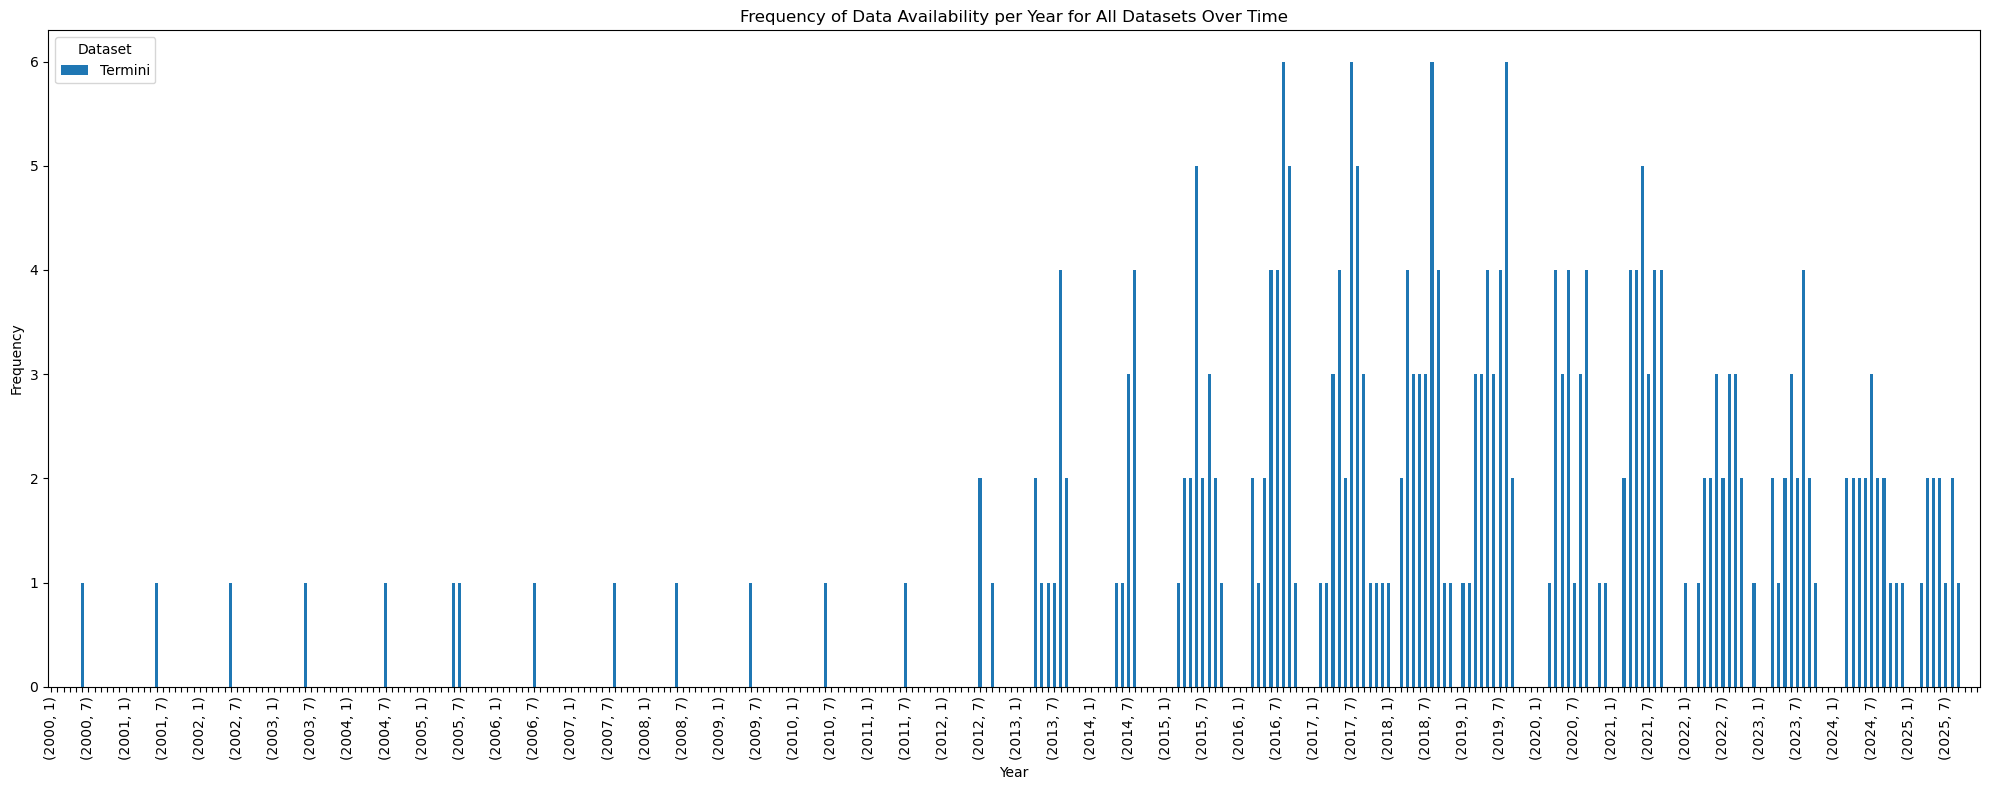

In [72]:
result = gpd.read_file('terminus_area_change_polygons.gpkg', layer='termini')
# Group each dataset by Year and Month and count occurrences
# nsidc_counts = zach_nsidc.groupby(['Year', 'Month']).size().rename('NSIDC')
# # autoterm_counts = zach_autoterm.groupby(['Year', 'Month']).size().rename('AutoTerm')
# termpicks_counts = zach_termpicks.groupby(['Year', 'Month']).size().rename('TermPicks')
# sofia_counts = sofia_termini.groupby(['Year', 'Month']).size().rename('Sofia Termini')

result['Year'] = pd.to_datetime(result['date']).dt.year
result['Month'] = pd.to_datetime(result['date']).dt.month
jensen_counts = result.groupby(['Year', 'Month']).size().rename('Termini')

# Create a complete index of all Year and Month combinations from 2000 to 2024
all_years_months = pd.MultiIndex.from_product(
    [range(2000, 2026), range(1, 13)], names=["Year", "Month"]
)

# Reindex each dataset to include all Year and Month combinations, filling missing values with 0
# nsidc_counts = nsidc_counts.reindex(all_years_months, fill_value=0)
# # autoterm_counts = autoterm_counts.reindex(all_years_months, fill_value=0)
# termpicks_counts = termpicks_counts.reindex(all_years_months, fill_value=0)
# sofia_counts = sofia_counts.reindex(all_years_months, fill_value=0)
jensen_counts = jensen_counts.reindex(all_years_months, fill_value=0)

# Combine all counts into a single DataFrame
# compiled_data = pd.concat([nsidc_counts, autoterm_counts, termpicks_counts, sofia_counts], axis=1).reset_index()
# compiled_data = pd.concat([nsidc_counts, termpicks_counts, sofia_counts, jensen_counts], axis=1).reset_index()
jensen_counts = pd.concat([jensen_counts], axis=1).reset_index()

# Fill NaN values with 0 (indicating no data for that dataset in a given month)
# compiled_data.fillna(0, inplace=True)
jensen_counts.fillna(0, inplace=True)

# Convert counts to integers
# compiled_data[['NSIDC', 'AutoTerm', 'TermPicks', 'Sofia Termini']] = compiled_data[['NSIDC', 'AutoTerm', 'TermPicks', 'Sofia Termini']].astype(int)
# compiled_data[['NSIDC', 'TermPicks', 'Sofia Termini', 'Jensen Termini']] = compiled_data[['NSIDC', 'TermPicks', 'Sofia Termini', 'Jensen Termini']].astype(int)
jensen_counts['Termini'] = jensen_counts['Termini'].astype(int)

# compiled_data.set_index(['Year', 'Month'], inplace=True)
jensen_counts.set_index(['Year', 'Month'], inplace=True)
jensen_counts
# compiled_data
# Convert to DataFrame
ax = jensen_counts.plot(kind='bar', stacked=True, figsize=(20, 8))

for i, t in enumerate(ax.get_xticklabels()):
    if (i % 6) != 0:
        t.set_visible(False)
        plt.xlabel('Year')
        
plt.ylabel('Frequency')
plt.title('Frequency of Data Availability per Year for All Datasets Over Time')
plt.legend(title='Dataset', loc='upper left')
plt.tight_layout()

# plt.savefig('zachariae_terminus_data_availability.png', dpi=300)
plt.show()

<Axes: >

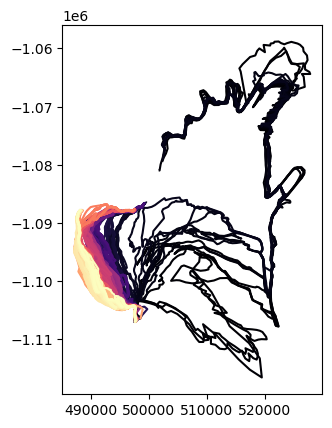

In [75]:
result.geometry.plot(cmap='magma')